In [ ]:
'''!pip install -q yfinance
!pip install -q -U watermark'''

In [57]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import warnings
warnings.filterwarnings('ignore')

In [58]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

sklearn   : 1.7.2
yfinance  : 0.2.65
matplotlib: 3.9.2
pandas    : 2.3.3
numpy     : 1.26.4



In [59]:
dados = yf.Ticker("^GSPC").history(period="max")

In [60]:
dados.head(3)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
1927-12-30 00:00:00-05:00,17.660000,17.660000,17.660000,17.660000,0,0.0,0.0
1928-01-03 00:00:00-05:00,17.760000,17.760000,17.760000,17.760000,0,0.0,0.0
1928-01-04 00:00:00-05:00,17.719999,17.719999,17.719999,17.719999,0,0.0,0.0


In [61]:
dados.tail(3)

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-12-02 00:00:00-05:00,6830.959961,6851.549805,6806.709961,6829.370117,4582290000,0.0,0.0
2025-12-03 00:00:00-05:00,6815.290039,6862.419922,6810.430176,6849.720215,4736780000,0.0,0.0
2025-12-04 00:00:00-05:00,6866.470215,6866.470215,6827.120117,6857.120117,2961946000,0.0,0.0


In [62]:
type(dados)

pandas.core.frame.DataFrame

In [63]:
dados.shape

(24599, 7)

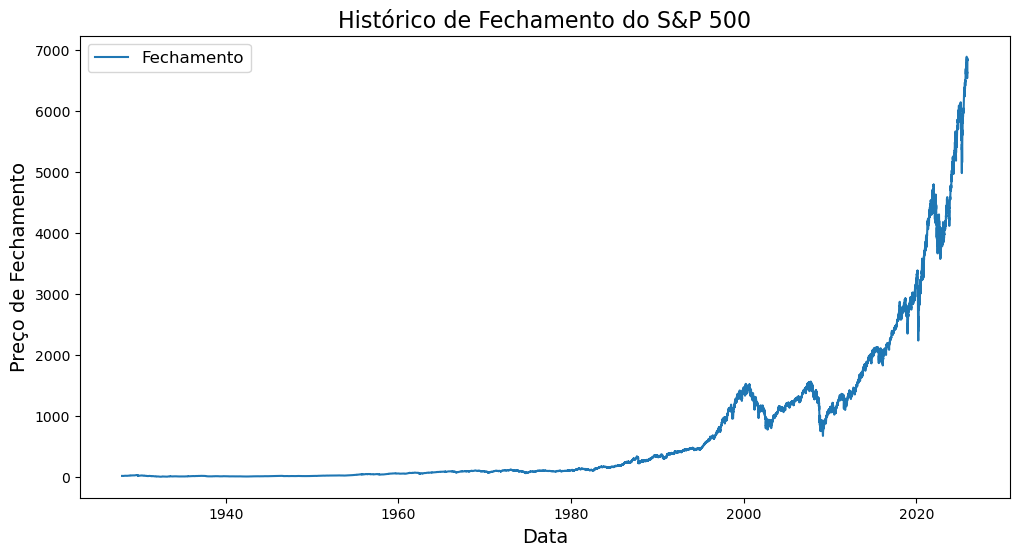

In [64]:
plt.figure(figsize=(12,6))
plt.plot(dados.index, dados['Close'], label = 'Fechamento')
plt.title('Histórico de Fechamento do S&P 500', fontsize = 16)
plt.xlabel('Data', fontsize = 14)
plt.ylabel('Preço de Fechamento', fontsize = 14)
plt.legend(loc = 'best', fontsize = 12)
plt.show()

In [65]:
del dados['Dividends']
del dados['Stock Splits']

In [66]:
dados["Valor_dia_seguinte"] = dados["Close"].shift(-1)

In [67]:
dados.tail(3)

,Open,High,Low,Close,Volume,Valor_dia_seguinte
Date,,,,,,
2025-12-02 00:00:00-05:00,6830.959961,6851.549805,6806.709961,6829.370117,4582290000,6849.720215
2025-12-03 00:00:00-05:00,6815.290039,6862.419922,6810.430176,6849.720215,4736780000,6857.120117
2025-12-04 00:00:00-05:00,6866.470215,6866.470215,6827.120117,6857.120117,2961946000,NaN


In [68]:
dados = dados.loc['1990-01-01':].copy()

In [69]:
dados = dados.dropna()

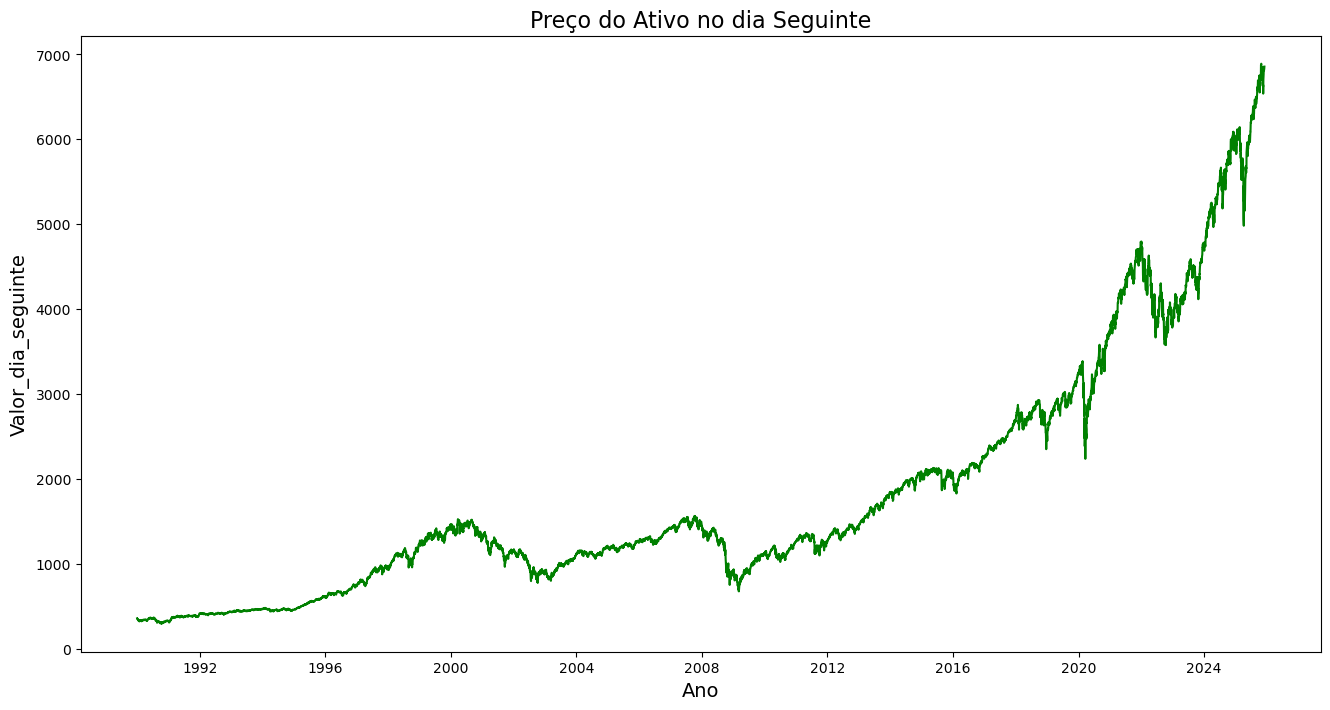

In [70]:
plt.figure(figsize=(16,8))
plt.plot(dados['Valor_dia_seguinte'], color = 'green')
plt.title('Preço do Ativo no dia Seguinte', fontsize = 16)
plt.xlabel('Ano', fontsize = 14)
plt.ylabel('Valor_dia_seguinte', fontsize = 14)
plt.show()

In [71]:
x = dados[['Open', 'High', 'Low', 'Close', 'Volume']]

In [72]:
y = dados['Valor_dia_seguinte']

In [73]:
x

,Open,High,Low,Close,Volume
Date,,,,,
1990-01-02 00:00:00-05:00,353.399994,359.690002,351.980011,359.690002,162070000
1990-01-03 00:00:00-05:00,359.690002,360.589996,357.890015,358.760010,192330000
1990-01-04 00:00:00-05:00,358.760010,358.760010,352.890015,355.670013,177000000
1990-01-05 00:00:00-05:00,355.670013,355.670013,351.350006,352.200012,158530000
1990-01-08 00:00:00-05:00,352.200012,354.239990,350.540009,353.790009,140110000
...,...,...,...,...,...
2025-11-26 00:00:00-05:00,6793.549805,6831.439941,6783.870117,6812.609863,4485000000
2025-11-28 00:00:00-05:00,6822.520020,6850.859863,6819.750000,6849.089844,2558540000
2025-12-01 00:00:00-05:00,6812.299805,6843.649902,6799.939941,6812.629883,4549370000


In [74]:
y

Date
1990-01-02 00:00:00-05:00     358.760010
1990-01-03 00:00:00-05:00     355.670013
1990-01-04 00:00:00-05:00     352.200012
1990-01-05 00:00:00-05:00     353.790009
1990-01-08 00:00:00-05:00     349.619995
                                ...     
2025-11-26 00:00:00-05:00    6849.089844
2025-11-28 00:00:00-05:00    6812.629883
2025-12-01 00:00:00-05:00    6829.370117
2025-12-02 00:00:00-05:00    6849.720215
2025-12-03 00:00:00-05:00    6857.120117
Name: Valor_dia_seguinte, Length: 9048, dtype: float64

In [75]:
x_treino, x_teste, y_treino, y_teste = train_test_split(x, y, test_size = 0.2, random_state = 42)

In [76]:
scaler = StandardScaler()

In [77]:
scaler.fit(x_treino)

,copy,True
,with_mean,True
,with_std,True


In [78]:
x_treino_scaled = scaler.transform(x_treino)

In [79]:
x_treino_scaled

array([[-0.96061025, -0.95986092, -0.95796705, -0.95756726, -1.18519974],
       [-0.36408484, -0.36662382, -0.35927432, -0.36215262, -0.34283161],
       [-0.99855904, -1.00096759, -0.99934036, -1.00175726, -1.26486518],
       ...,
       [-0.32941182, -0.3320088 , -0.32756375, -0.32880677,  0.55846843],
       [-0.95619808, -0.95556108, -0.95355183, -0.95319035, -1.22303139],
       [ 0.64982106,  0.65220592,  0.66037382,  0.66150505,  0.51472126]])

In [80]:
x_teste_scaled = scaler.transform(x_teste)

In [81]:
x_teste_scaled

array([[-0.30313529, -0.30544893, -0.2987661 , -0.30325369, -0.00415382],
       [-0.92346113, -0.92547624, -0.92079033, -0.92323935, -1.20841003],
       [ 0.09205115,  0.08869065,  0.09294726,  0.08865544,  0.32696083],
       ...,
       [-0.26939526, -0.2668691 , -0.26295765, -0.26109786,  0.11045727],
       [ 0.11478537,  0.11432209,  0.12333194,  0.12005841,  0.16748644],
       [-0.36495464, -0.37046295, -0.37626514, -0.38020747,  0.13544806]])

In [82]:
modelo = LinearRegression()

In [83]:
modelo.fit(x_treino_scaled, y_treino)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:
modelo.coef_

array([-5.85191673e+01,  1.99192575e+02,  2.15574122e+02,  1.06990781e+03,
       -1.00235409e-01])

In [86]:
modelo.intercept_

1812.9337352110754

In [87]:
y_pred = modelo.predict(x_teste_scaled)

In [88]:
y_pred

array([1380.97048257,  496.46748339, 1940.07090098, ..., 1439.49160473,
       1984.01052192, 1272.58355848])

In [90]:
print('MAE:', metrics.mean_absolute_error(y_teste, y_pred))
print('MSE:', metrics.mean_squared_error(y_teste, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred)))
print('R2:', metrics.r2_score(y_teste, y_pred))

MAE: 13.01767589130474
MSE: 565.6702622194338
RMSE: 23.783823540789943
R2: 0.9997202141876207


Text(0.5, 1.0, 'Real x Previsto')

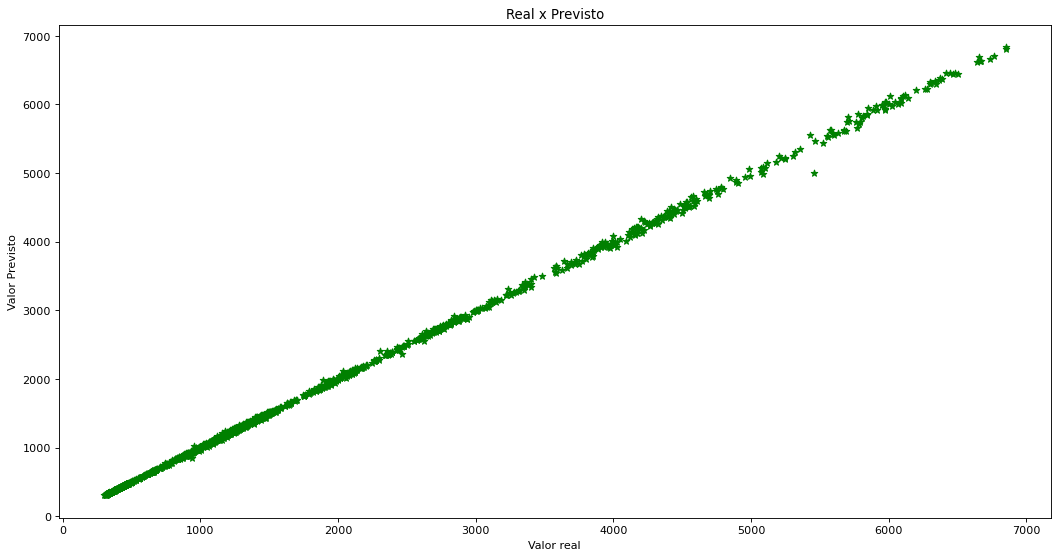

In [92]:
plt.figure(figsize = (16,8), dpi = 80)
plt.scatter(y_teste, y_pred, color = 'green', marker = "*")
plt.xlabel('Valor real')
plt.ylabel('Valor Previsto')
plt.title('Real x Previsto')

In [93]:
novos_dados = pd.DataFrame({
    'Open': [4500.00],
    'High': [4550.00],
    'Low': [4490.00],
    'Close': [4540.00],
    'Volume': [3000000000]
})

In [94]:
novos_dados_scaled = scaler.transform(novos_dados)

In [95]:
previsao_novos_dados = modelo.predict(novos_dados_scaled)

In [97]:
print('Previsão do valor de fechamento para o próximo dia:', previsao_novos_dados[0])

Previsão do valor de fechamento para o próximo dia: 4537.687036285276
